# 16 - Uso de Word2Vec Preentrenado
 
Goal: Ejemplo de uso de embeddings Word2Vec preentrenados en un modelo Keras simple.
 
Run with: conda activate tfenv

In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import plotly.express as px
import pandas as pd
import time

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [94]:
# Importar embeddings Word2Vec entrenados previamente
class MyWord2Vec():
	def __init__(self, path='myWord2Vec/'):
		super(MyWord2Vec, self).__init__()
		target_embeddings = np.load(path + 'target_embeddings.npy')
		context_embeddings = np.load(path + 'context_embeddings.npy')
		text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()
		self.layer = layers.Embedding(
			input_dim=target_embeddings.shape[0],
			output_dim=target_embeddings.shape[1],
			weights=[target_embeddings],
			trainable=False,  # O True si quieres ajustar
			name='pretrained_embedding'
		)
		self.target_embeddings = target_embeddings
		self.context_embeddings = context_embeddings
		self.text_vocab = text_vocab
		self.final_embeddings = (target_embeddings + context_embeddings) / 2
		print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape, 'Vocabulario cargado:', len(text_vocab))

	def __call__(self, token):
		token_id = self.text_vocab.get(token)
		if token_id is None:
			raise ValueError(f"Token '{token}' no encontrado en el vocabulario.")
		return self.final_embeddings[token_id]

myWord2Vec = MyWord2Vec()

Embeddings cargados: (807, 64) (807, 64) Vocabulario cargado: 807


In [98]:
myWord2Vec('bank')

array([-0.28501534, -0.5073903 ,  0.3754411 , -0.16484009, -0.1826826 ,
       -0.5811516 ,  0.25318754, -0.20066723, -0.03234106, -0.1983294 ,
        0.22193125, -0.07133868, -1.1277426 , -0.14788602,  0.00594485,
        0.06697989,  0.2680027 ,  0.30610293,  0.02022836, -0.14936   ,
       -0.35025677,  0.9948102 , -0.29224348,  0.27824396, -0.06160453,
        0.96823585, -1.0880908 ,  0.20591159,  0.35358378,  0.03991617,
       -0.0276342 ,  0.5968418 ,  0.7929538 ,  0.74884087,  0.40281463,
        0.12895238,  0.45341355, -1.1052495 , -0.4245516 ,  0.03584774,
        0.6724809 ,  0.08946411, -0.08444281, -0.40274462,  0.22121572,
       -1.2098794 ,  0.04220062,  0.5373121 , -0.3225735 ,  0.08055313,
       -0.16905993, -0.16546796, -0.26491246, -0.31321383,  0.10717484,
       -0.14396463, -0.86192745,  0.5560495 ,  0.08061355, -0.07986355,
        0.5029609 , -0.38039207,  0.655138  ,  0.38013253], dtype=float32)

In [100]:
# Ejemplo: Clasificación de palabras (dummy) usando embeddings preentrenados
import random

# Selecciona palabras reales del vocabulario
vocab_list = list(myWord2Vec.text_vocab.keys())
# Ejemplo: palabras de la ciudad de Londres y otras del dataset
palabras = ['london', 'bank', 'palace', 'bridge', 'river', 'museum', 'football', 'rain', 'queen', 'underground']
palabras = [p for p in palabras if p in vocab_list]
etiquetas = [1 if p in ['london', 'palace', 'museum', 'queen'] else 0 for p in palabras]  # 1=relacionado a cultura/monarquía, 0=otro

# Si quieres más ejemplos aleatorios del vocabulario:
while len(palabras) < 10:
    p = random.choice(vocab_list)
    if p not in palabras:
        palabras.append(p)
        etiquetas.append(0)  # Por defecto, clase 0

# Obtener índices de palabras en el vocabulario
indices = [myWord2Vec.text_vocab[p] for p in palabras]
y = np.array(etiquetas)
X = np.array(indices)

# Modelo simple: toma el embedding y lo pasa por una capa densa
model = keras.Sequential([
    layers.Input(shape=(), dtype='int32'),
    myWord2Vec.layer,  # Capa de embedding preentrenada
    layers.Flatten(),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Dataset para entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((X, y)).batch(2)

history = model.fit(
    train_ds,
    epochs=20,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 64)             │        51,648 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,177 (203.82 KB)

 Trainable params: 529 (2.07 KB)

 Non-trainable params: 51,648 (201.75 KB)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 0.8437
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.7856 
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.7395 
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6979 
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6608 
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6294 
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6016 
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.5770 
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.5554 
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.5368 
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.5202 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.5054 
Ep

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
       Palabra  Etiqueta_verdadera  Predicción  Predicción_binaria
0       london                   1        0.45                   0
1         bank                   0        0.19                   0
2       palace                   1        0.58                   1
3       bridge                   0        0.23                   0
4        river                   0        0.39                   0
5       museum                   1        0.72                   1
6        queen                   1        0.91                   1
7  underground                   0        0.64                   1
8     services                   0        0.20                   0
9      lambeth                   0        0.11                   0


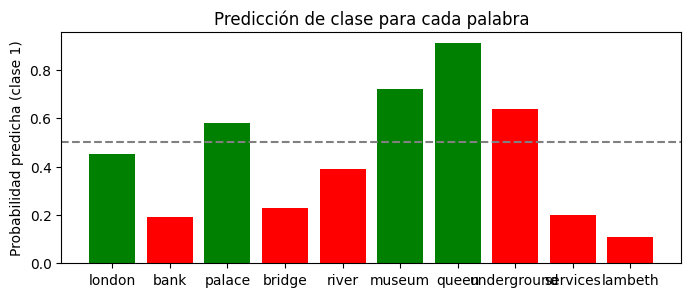

In [101]:
# Visualización de resultados: predicciones vs etiquetas verdaderas
import matplotlib.pyplot as plt
import pandas as pd

# Obtener predicciones del modelo
y_pred = model.predict(X).flatten()
y_pred_bin = (y_pred > 0.5).astype(int)

# Mostrar resultados en tabla
df = pd.DataFrame({
    'Palabra': palabras,
    'Etiqueta_verdadera': y,
    'Predicción': y_pred.round(2),
    'Predicción_binaria': y_pred_bin
})
print(df)

# Gráfico de barras de las predicciones
plt.figure(figsize=(8,3))
plt.bar(df['Palabra'], df['Predicción'], color=['green' if t==1 else 'red' for t in y])
plt.axhline(0.5, color='gray', linestyle='--')
plt.ylabel('Probabilidad predicha (clase 1)')
plt.title('Predicción de clase para cada palabra')
plt.show()